# Assignment 3 — Linear Regression (100% Manual, No Libraries)

**Dataset:** `train.csv` (1000 rows) and `test.csv` (300 rows), each with a single input `x` and output `y`.

**Goal:** Fit a simple linear regression line $y_i = \beta_0 + \beta_1 x_i$ using the training data, then evaluate it on the test data with Mean Squared Error — all implemented with **pure Python** (`list`s, `for` loops, built-in `math`/`csv` modules only). **No `numpy`, `pandas`, or `sklearn` anywhere.** `matplotlib` is used only at the end to draw the regression line.

### Coding Steps (as per assignment brief)
1. Line: $y_i = \beta_0 + \beta_1 x_i$
2. From the training file, compute $\beta_1$ and $\beta_0$:
$$\beta_1 = \frac{SS_{xy}}{SS_{xx}}, \qquad \beta_0 = \bar{y} - \beta_1 \bar{x}$$
where
$$SS_{xy} = \sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y}) = \sum_{i=1}^{n} y_i x_i - n\bar{x}\bar{y}$$
$$SS_{xx} = \sum_{i=1}^{n}(x_i-\bar{x})^2 = \sum_{i=1}^{n} x_i^2 - n(\bar{x})^2$$
($n$ = length of training dataset)
3. For each row in the test dataset, compute the error $\varepsilon_i$ = (predicted output) − (given output).
4. Compute Mean Squared Error and print the result:
$$MSE = \frac{1}{2n}\sum_{i=1}^{n}\varepsilon_i^2$$
($n$ = length of test dataset)


## 1. Load the Dataset

Two options are given below:

- **Option A (default):** load your own `train.csv` / `test.csv` directly from **Google Drive** (mounts your Drive, then reads the files by path).
- **Option B (fallback):** use the datasets embedded in this notebook, in case you don't want to mount Drive.

Set `USE_DRIVE = True` to use your own Drive files, or `False` to use the embedded fallback data. Either way, we read them with Python's built-in `csv` module — **not** `pandas`.


In [6]:
import csv
import io
import math

USE_DRIVE = False

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

    train_path = "/content/drive/My Drive/train.csv"
    test_path = "/content/drive/My Drive/test.csv"

    with open(train_path, "r") as f:
        train_rows = list(csv.reader(f))
    with open(test_path, "r") as f:
        test_rows = list(csv.reader(f))
else:
    train_csv_text = """x,y
24,21.54945196
50,47.46446305
15,17.21865634
38,36.58639803
87,87.28898389
36,32.46387493
12,10.78089683
81,80.7633986
25,24.61215147
5,6.963319071
16,11.23757338
16,13.53290206
24,24.60323899
39,39.40049976
54,48.43753838
60,61.69900319
26,26.92832418
73,70.4052055
29,29.34092408
31,25.30895192
68,69.02934339
87,84.99484703
58,57.04310305
54,50.5921991
84,83.02772202
58,57.05752706
49,47.95883341
20,24.34226432
90,94.68488281
48,48.03970696
4,7.08132338
25,21.99239907
42,42.33151664
0,0.329089443
60,61.92303698
93,91.17716423
39,39.45358014
7,5.996069607
21,22.59015942
68,61.18044414
84,85.02778957
0,-1.28631089
58,61.94273962
19,21.96033347
36,33.66194193
19,17.60946242
59,58.5630564
51,52.82390762
19,22.1363481
33,35.07467353
85,86.18822311
44,42.63227697
5,4.09817744
59,61.2229864
14,17.70677576
9,11.85312574
75,80.23051695
69,62.64931741
10,9.616859804
17,20.02797699
58,61.7510743
74,71.61010303
21,23.77154623
51,51.90142035
19,22.66073682
50,50.02897927
24,26.68794368
0,0.376911899
12,6.806419002
75,77.33986001
21,28.90260209
64,66.7346608
5,0.707510638
58,57.07748383
32,28.41453196
41,44.46272123
7,7.459605998
4,2.316708112
5,4.928546187
49,52.50336074
90,91.19109623
3,8.489164326
11,6.963371967
32,31.97989959
83,81.4281205
25,22.62365422
83,78.52505087
26,25.80714057
76,73.51081775
95,91.775467
53,49.21863516
77,80.50445387
42,50.05636123
25,25.46292549
54,55.32164264
55,59.1244888
0,1.100686692
73,71.98020786
35,30.13666408
86,83.88427405
90,89.91004752
13,8.335654576
46,47.88388961
46,45.00397413
32,31.15664574
8,9.190375682
71,74.83135003
28,30.23177607
24,24.21914027
56,57.87219151
49,50.61728392
79,78.67470043
90,86.236707
89,89.10409255
41,43.26595082
27,26.68273277
58,59.46383041
26,28.90055826
31,31.300416
70,71.1433266
71,68.4739206
39,39.98238856
7,4.075776144
48,47.85817542
56,51.20390217
45,43.9367213
41,38.13626679
3,3.574661632
37,36.4139958
24,22.21908523
68,63.5312572
47,49.86702787
27,21.53140009
68,64.05710234
74,70.77549842
95,92.15749762
79,81.22259156
21,25.10114067
95,94.08853397
54,53.25166165
56,59.16236621
80,75.24148428
26,28.22325833
25,25.33323728
8,6.364615703
95,95.4609216
94,88.64183756
54,58.70318693
7,6.815491279
99,99.40394676
36,32.77049249
48,47.0586788
65,60.53321778
42,40.30929858
93,89.42222685
86,86.82132066
26,26.11697543
51,53.26657596
100,96.62327888
94,95.78441027
6,6.047286687
24,24.47387908
75,75.96844763
7,3.829381009
53,52.51703683
73,72.80457527
16,14.10999096
80,80.86087062
77,77.01988215
89,86.26972444
80,77.13735466
55,51.47649476
19,17.34557531
56,57.72853572
47,44.15029394
56,59.24362743
2,-1.053275611
82,86.79002254
57,60.14031858
44,44.04222058
26,24.5227488
52,52.95305521
41,43.16133498
44,45.67562576
3,-2.830749501
31,29.19693178
97,96.49812401
21,22.5453232
17,20.10741433
7,4.035430253
61,61.14568518
10,13.97163653
52,55.34529893
10,12.18441166
65,64.00077658
71,70.3188322
4,-0.936895047
24,18.91422276
26,23.87590331
51,47.5775361
42,43.2736092
62,66.48278755
74,75.72605529
77,80.59643338
3,-2.235879852
50,47.04654956
24,21.59635575
37,32.87558963
58,57.95782956
52,52.24760027
27,24.58286902
14,12.12573805
100,100.0158026
35,30.157
72,74.04682658
5,1.611947467
71,70.36836307
54,52.26831735
84,83.1286166
42,43.64765048
54,49.44785426
74,72.6356699
54,52.78130641
53,57.11195136
78,79.1050629
97,101.6228548
49,53.5825402
71,68.92139297
48,46.9666961
51,51.02642868
89,85.52073551
99,99.51685756
93,94.63911256
49,46.78357742
18,21.21321959
65,58.37266004
83,87.22059677
100,102.4967859
41,43.88314335
52,53.06655757
29,26.33464785
97,98.52008934
7,9.400497579
51,52.94026699
58,53.83020877
50,45.94511142
67,65.0132736
89,86.5069584
76,75.63280796
35,36.78035027
99,100.5328916
31,29.04466136
52,51.70352433
11,9.199954718
66,71.70015848
50,49.82634062
39,37.49971096
60,53.65084683
35,33.92561965
53,49.92639685
14,8.148154262
49,49.72359037
16,16.16712757
76,75.30033002
13,9.577368568
51,48.38088357
70,72.95331671
98,92.59573853
86,88.85523586
100,99.00361771
46,45.09439571
51,46.94362684
50,48.33449605
91,94.92329574
48,47.78165248
81,81.28960746
38,37.83155021
40,39.69185252
79,76.92664854
96,88.02990531
60,56.99178872
70,72.58929383
44,44.98103442
11,11.99017641
6,1.919513328
5,1.628826073
72,66.27746655
55,57.53887255
95,94.70291077
41,41.21469904
25,25.04169243
1,3.778209914
55,50.50711779
4,9.682408486
48,48.88147608
55,54.40348599
75,71.70233156
68,69.35848388
100,99.98491591
25,26.03323718
75,75.48910307
34,36.59623056
38,40.95102191
92,86.78316267
21,15.50701184
88,85.86077871
75,79.20610113
76,80.80643766
44,48.59717283
10,13.93415049
21,27.3051179
16,14.00226297
32,33.67416
13,13.11612884
26,24.76649193
70,73.68477876
77,77.53149541
77,76.24503196
88,88.0578931
35,35.02445799
24,21.65857739
17,17.33681562
91,94.36778957
32,33.43396307
36,32.52179399
89,90.57741298
69,71.25634126
30,31.23212856
6,5.398840061
22,18.56241391
67,71.97121038
9,5.225759566
74,73.5964342
50,49.76948983
85,82.69087513
3,1.652309089
0,-3.836652144
59,62.03811556
62,61.26514581
17,13.24991628
90,88.61672694
23,21.13655528
19,23.85017475
93,92.01203405
14,10.26712261
58,54.14681616
87,87.00645713
37,37.69447352
20,19.62278654
35,34.78561007
63,62.03190983
56,52.67003801
62,58.09031476
98,97.19448821
90,90.50155298
51,50.5123462
93,94.45211871
22,21.10794636
38,37.36298431
13,10.28574844
98,96.04932416
99,100.0953697
31,30.6063167
94,96.19000542
73,71.30828034
37,34.59311043
23,19.02332876
11,10.76669688
88,90.5799868
47,48.71787679
79,78.74139764
91,85.23492274
71,71.65789964
10,8.938990554
39,39.89606046
92,91.85091116
99,99.11200375
28,26.22196486
32,33.21584226
32,35.72392691
75,76.88604495
99,99.30874567
27,25.77161074
64,67.85169407
98,98.50371084
38,31.11331895
46,45.51171028
13,12.65537808
96,95.56065366
9,9.526431641
34,36.10893209
49,46.43628318
1,-3.83998112
50,48.97302037
94,93.25305499
27,23.47650968
20,17.13551132
12,14.55896144
45,41.53992729
91,91.64730552
61,66.16652565
10,9.230857489
47,47.41377893
33,34.76441561
84,86.10796637
24,21.81267954
48,48.89963951
48,46.78108638
9,12.91328547
93,94.55203143
99,94.97068753
8,2.379172481
20,21.47982988
38,35.79795462
78,82.0763803
81,78.87097714
42,47.2492425
95,96.18852325
78,78.38491927
44,42.94274064
68,64.43231595
87,84.21191485
58,57.3069783
52,52.52101436
26,25.7440243
75,75.42283401
48,53.62523007
71,75.14466308
77,74.12151511
34,36.24807243
24,20.21665898
70,66.94758118
29,34.07278254
76,73.13850045
98,92.85929155
28,28.36793808
87,85.59308727
9,10.68453755
87,86.10708624
33,33.22031418
64,66.09563422
17,19.30486546
49,48.84542083
95,93.73176312
75,75.45758614
89,91.24239226
81,87.15690853
25,25.53752833
47,46.06629478
50,49.65277661
5,7.382244165
68,71.11189935
84,83.50570521
8,8.791139893
41,33.30638903
26,26.40362524
89,91.72960726
78,82.53030719
34,36.67762733
92,86.98450355
27,32.34784175
12,16.78353974
2,1.576584383
22,17.4618141
0,2.116113029
26,24.34804332
50,48.29491198
84,85.52145453
70,73.71434779
66,63.15189497
42,38.46213684
19,19.47100788
94,94.07428225
71,67.92051286
19,22.58096241
16,16.01629889
49,48.43307886
29,29.6673599
29,26.65566328
86,86.28206739
50,50.82304924
86,88.57251713
30,32.59980745
23,21.02469368
20,20.72894979
16,20.38051187
57,57.25180153
8,6.967537054
8,10.240085
62,64.94841088
55,55.35893915
30,31.24365589
86,90.72048818
62,58.750127
51,55.85003198
61,60.19925869
86,85.03295412
61,60.38823085
21,18.44679787
81,82.18839247
97,94.2963344
5,7.682024586
61,61.01858089
47,53.60562216
98,94.47728801
30,27.9645947
63,62.55662585
0,1.406254414
100,101.7003412
18,13.84973988
30,28.99769315
98,99.04315693
16,15.56135514
22,24.63528393
55,53.98393374
43,42.91449728
75,74.29662112
91,91.17012883
46,49.42440876
85,82.47683519
55,56.15303953
36,37.17063131
49,46.36928662
94,97.02383456
43,40.83182104
22,24.08498313
37,41.14386358
24,21.97388066
95,100.740897
61,61.19971596
75,74.39517002
68,69.04377173
58,56.68718792
5,5.860391715
53,55.72021356
80,79.22021816
83,86.30177517
25,25.26971886
34,36.33294447
26,27.65574228
90,94.79690531
60,58.67366671
49,56.15934471
19,18.40919388
92,86.26936988
29,26.59436195
8,8.452520159
57,56.18131518
29,27.65452669
19,20.87391785
81,77.83354439
50,50.01787825
15,9.290856256
70,75.0284725
39,38.3037698
43,44.70786405
21,22.51016575
98,102.4959452
86,86.76845244
16,13.89748578
25,24.81824269
31,33.94224862
93,92.26970059
67,68.73365081
49,47.38516883
25,32.37576914
88,87.67388681
54,54.57648371
21,18.06450222
8,7.896539841
32,35.00341078
35,36.72823317
67,65.84975426
90,89.59295492
59,61.69026202
15,11.60499315
67,71.0826803
42,43.71901164
44,41.57421008
77,74.25552425
68,66.28310437
36,36.62438077
11,10.32374866
10,7.156457657
65,67.88603132
98,101.1097591
98,98.6132033
49,50.19083844
31,27.83896261
56,55.9249564
70,76.47340872
91,92.05756378
25,27.35245439
54,55.32083476
39,41.39990349
91,93.59057024
3,5.297054029
22,21.01429422
2,2.267059451
2,-0.121860502
65,66.49546208
71,73.83637687
42,42.10140878
76,77.35135732
43,41.02251779
8,14.75305272
86,83.28199022
87,89.93374342
3,2.286571686
58,55.61421297
62,62.15313408
89,89.55803528
95,94.00291863
28,26.78023848
0,-0.764537626
1,0.282866003
49,44.26800515
21,19.85174138
46,47.15960005
11,8.359366572
89,92.08157084
37,41.88734051
29,30.5413129
44,46.87654473
96,96.35659485
16,17.9170699
74,71.67949917
35,32.64997554
42,39.34482965
16,17.03401999
56,52.87524074
18,15.85414849
100,108.8716183
54,49.30477253
92,89.4749477
63,63.67348242
81,83.78410946
73,73.51136922
48,46.80297244
1,5.809946802
85,85.23027975
14,10.58213964
25,21.37698317
45,46.0537745
98,95.2389253
97,94.15149206
58,54.54868046
93,87.36260449
88,88.47741598
89,84.48045678
47,48.79647071
6,10.76675683
34,30.48882921
30,29.76846185
16,13.51574749
86,86.12955884
40,43.30022747
52,51.92110232
15,16.49185287
4,7.998073432
95,97.66689567
99,89.80545367
35,38.07166567
58,60.27852322
10,6.709195759
16,18.35488924
53,56.37058203
58,62.80064204
42,41.25155632
24,19.42637541
84,82.88935804
64,63.61364981
12,11.29627199
61,60.02274882
75,72.60339326
15,11.87964573
100,100.7012737
43,45.12420809
13,14.81106804
48,48.09368034
45,42.29145672
52,52.73389794
34,36.72396986
30,28.64535198
65,62.16675273
100,95.58459518
67,66.04325304
99,99.9566225
45,46.14941984
87,89.13754963
73,69.71787806
9,12.31736648
81,78.20296268
72,71.30995371
81,81.45544709
58,58.59500642
93,94.62509374
82,88.60376995
66,63.64868529
97,94.9752655
77,79.77515201
21,23.17727887
22,25.60926156
20,17.85738813
36,41.84986439
15,9.805234876
62,58.87465933
95,97.61793701
20,18.39512747
5,8.746747654
4,2.811415826
19,17.09537241
96,95.14907176
62,61.38800663
36,40.24701716
15,14.82248589
65,66.95806869
14,16.63507984
87,90.65513736
69,77.22982636
89,92.11906278
51,46.91387709
89,89.82634442
27,21.71380347
97,97.41206981
58,57.01631363
79,78.31056542
21,19.1315097
93,93.03483388
27,26.59112396
99,97.55155344
31,31.43524822
33,35.12724777
80,78.61042432
28,33.07112825
47,51.69967172
53,53.62235225
69,69.46306072
28,27.42497237
33,36.34644189
91,95.06140858
71,68.16724757
50,50.96155532
76,78.04237454
4,5.607664865
37,36.11334779
70,67.2352155
68,65.01324035
40,38.14753871
35,34.31141446
94,95.28503937
88,87.84749912
52,54.08170635
31,31.93063515
59,59.61247085
0,-1.040114209
39,47.49374765
64,62.60089773
69,70.9146434
57,56.14834113
13,14.05572877
72,68.11367147
76,75.59701346
61,59.225745
82,85.45504157
18,17.76197116
41,38.68888682
50,50.96343637
55,51.83503872
13,17.0761107
46,46.56141773
13,10.34754461
79,77.91032969
53,50.17008622
15,13.25690647
28,31.32274932
81,73.9308764
69,74.45114379
52,52.01932286
84,83.68820499
68,70.3698748
27,23.44479161
56,49.83051801
48,49.88226593
40,41.04525583
39,33.37834391
82,81.29750133
100,105.5918375
59,56.82457013
43,48.67252645
67,67.02150613
38,38.43076389
63,58.61466887
91,89.12377509
60,60.9105427
14,13.83959878
21,16.89085185
87,84.06676818
73,70.34969772
32,33.38474138
2,-1.63296825
82,88.54475895
19,17.44047622
74,75.69298554
42,41.97607107
12,12.59244741
1,0.275307261
90,98.13258005
89,87.45721555
0,-2.344738542
41,39.3294153
16,16.68715211
94,96.58888601
97,97.70342201
66,67.01715955
24,25.63476257
17,13.41310757
90,95.15647284
13,9.744164258
0,-3.467883789
64,62.82816355
96,97.27405461
98,95.58017185
12,7.468501839
41,45.44599591
47,46.69013968
78,74.4993599
20,21.63500655
89,91.59548851
29,26.49487961
64,67.38654703
75,74.25362837
12,12.07991648
25,21.32273728
28,29.31770045
30,26.48713683
65,68.94699774
59,59.10598995
64,64.37521087
53,60.20758349
71,70.34329706
97,97.1082562
73,75.7584178
9,10.80462727
12,12.11219941
63,63.28312382
99,98.03017721
60,63.19354354
35,34.8534823
2,-2.819913974
60,59.8313966
32,29.38505024
94,97.00148372
84,85.18657275
63,61.74063192
22,18.84798163
81,78.79008525
93,95.12400481
33,30.48881287
7,10.41468095
42,38.98317436
46,46.11021062
54,52.45103628
16,21.16523945
49,52.28620611
43,44.18863945
95,97.13832018
66,67.22008001
21,18.98322306
35,24.3884599
80,79.44769523
37,40.03504862
54,53.32005764
56,54.55446979
1,-2.761182595
32,37.80182795
58,57.48741435
32,36.06292994
46,49.83538167
72,74.68953276
17,14.86159401
97,101.0697879
93,99.43577876
91,91.69240746
37,34.12473248
4,6.079390073
54,59.07247174
51,56.43046022
27,30.49412933
46,48.35172635
92,89.73153611
73,72.86282528
77,80.97144285
91,91.36566374
61,60.07137496
99,99.87382707
4,8.655714172
72,69.39858505
19,19.38780134
57,53.11628433
78,78.39683006
26,25.75612514
74,75.07484683
90,92.88772282
66,69.45498498
13,13.12109842
40,48.09843134
77,79.3142548
67,68.48820749
75,73.2300846
23,24.68362712
45,41.90368917
59,62.22635684
44,45.96396877
23,23.52647153
55,51.80035866
55,51.10774273
95,95.79747345
12,9.241138977
4,7.646529763
7,9.281699753
100,103.5266162
48,47.41006725
42,42.03835773
96,96.11982476
39,38.05766408
100,105.4503788
87,88.80306911
14,15.49301141
14,12.42624606
37,40.00709598
5,5.634030902
88,87.36938931
91,89.73951993
65,66.61499643
74,72.9138853
56,57.19103506
16,11.21710477
5,0.676076749
28,28.15668543
92,95.3958003
46,52.05490703
54,59.70864577
39,36.79224762
44,37.08457698
31,24.18437976
68,67.28725332
86,82.870594
90,89.899991
38,36.94173178
21,19.87562242
95,90.71481654
56,61.09367762
60,60.11134958
65,64.83296316
78,81.40381769
89,92.40217686
6,2.576625376
67,63.80768172
36,38.67780759
16,16.82839701
100,99.78687252
45,44.68913433
73,71.00377824
57,51.57326718
20,19.87846479
76,79.50341495
34,34.58876491
55,55.7383467
72,68.19721905
55,55.81628509
8,9.391416798
56,56.01448111
72,77.9969477
58,55.37049953
6,11.89457829
96,94.79081712
23,25.69041546
58,53.52042319
23,18.31396758
19,21.42637785
25,30.41303282
64,67.68142149
21,17.0854783
59,60.91792707
19,14.99514319
16,16.74923937
42,41.46923883
43,42.84526108
61,59.12912974
92,91.30863673
11,8.673336357
41,39.31485292
1,5.313686205
8,5.405220518
71,68.5458879
46,47.33487629
55,54.09063686
62,63.29717058
47,52.45946688"""
    test_csv_text = """x,y
77,79.77515201
21,23.17727887
22,25.60926156
20,17.85738813
36,41.84986439
15,9.805234876
62,58.87465933
95,97.61793701
20,18.39512747
5,8.746747654
4,2.811415826
19,17.09537241
96,95.14907176
62,61.38800663
36,40.24701716
15,14.82248589
65,66.95806869
14,16.63507984
87,90.65513736
69,77.22982636
89,92.11906278
51,46.91387709
89,89.82634442
27,21.71380347
97,97.41206981
58,57.01631363
79,78.31056542
21,19.1315097
93,93.03483388
27,26.59112396
99,97.55155344
31,31.43524822
33,35.12724777
80,78.61042432
28,33.07112825
47,51.69967172
53,53.62235225
69,69.46306072
28,27.42497237
33,36.34644189
91,95.06140858
71,68.16724757
50,50.96155532
76,78.04237454
4,5.607664865
37,36.11334779
70,67.2352155
68,65.01324035
40,38.14753871
35,34.31141446
94,95.28503937
88,87.84749912
52,54.08170635
31,31.93063515
59,59.61247085
0,-1.040114209
39,47.49374765
64,62.60089773
69,70.9146434
57,56.14834113
13,14.05572877
72,68.11367147
76,75.59701346
61,59.225745
82,85.45504157
18,17.76197116
41,38.68888682
50,50.96343637
55,51.83503872
13,17.0761107
46,46.56141773
13,10.34754461
79,77.91032969
53,50.17008622
15,13.25690647
28,31.32274932
81,73.9308764
69,74.45114379
52,52.01932286
84,83.68820499
68,70.3698748
27,23.44479161
56,49.83051801
48,49.88226593
40,41.04525583
39,33.37834391
82,81.29750133
100,105.5918375
59,56.82457013
43,48.67252645
67,67.02150613
38,38.43076389
63,58.61466887
91,89.12377509
60,60.9105427
14,13.83959878
21,16.89085185
87,84.06676818
73,70.34969772
32,33.38474138
2,-1.63296825
82,88.54475895
19,17.44047622
74,75.69298554
42,41.97607107
12,12.59244741
1,0.275307261
90,98.13258005
89,87.45721555
0,-2.344738542
41,39.3294153
16,16.68715211
94,96.58888601
97,97.70342201
66,67.01715955
24,25.63476257
17,13.41310757
90,95.15647284
13,9.744164258
0,-3.467883789
64,62.82816355
96,97.27405461
98,95.58017185
12,7.468501839
41,45.44599591
47,46.69013968
78,74.4993599
20,21.63500655
89,91.59548851
29,26.49487961
64,67.38654703
75,74.25362837
12,12.07991648
25,21.32273728
28,29.31770045
30,26.48713683
65,68.94699774
59,59.10598995
64,64.37521087
53,60.20758349
71,70.34329706
97,97.1082562
73,75.7584178
9,10.80462727
12,12.11219941
63,63.28312382
99,98.03017721
60,63.19354354
35,34.8534823
2,-2.819913974
60,59.8313966
32,29.38505024
94,97.00148372
84,85.18657275
63,61.74063192
22,18.84798163
81,78.79008525
93,95.12400481
33,30.48881287
7,10.41468095
42,38.98317436
46,46.11021062
54,52.45103628
16,21.16523945
49,52.28620611
43,44.18863945
95,97.13832018
66,67.22008001
21,18.98322306
35,24.3884599
80,79.44769523
37,40.03504862
54,53.32005764
56,54.55446979
1,-2.761182595
32,37.80182795
58,57.48741435
32,36.06292994
46,49.83538167
72,74.68953276
17,14.86159401
97,101.0697879
93,99.43577876
91,91.69240746
37,34.12473248
4,6.079390073
54,59.07247174
51,56.43046022
27,30.49412933
46,48.35172635
92,89.73153611
73,72.86282528
77,80.97144285
91,91.36566374
61,60.07137496
99,99.87382707
4,8.655714172
72,69.39858505
19,19.38780134
57,53.11628433
78,78.39683006
26,25.75612514
74,75.07484683
90,92.88772282
66,69.45498498
13,13.12109842
40,48.09843134
77,79.3142548
67,68.48820749
75,73.2300846
23,24.68362712
45,41.90368917
59,62.22635684
44,45.96396877
23,23.52647153
55,51.80035866
55,51.10774273
95,95.79747345
12,9.241138977
4,7.646529763
7,9.281699753
100,103.5266162
48,47.41006725
42,42.03835773
96,96.11982476
39,38.05766408
100,105.4503788
87,88.80306911
14,15.49301141
14,12.42624606
37,40.00709598
5,5.634030902
88,87.36938931
91,89.73951993
65,66.61499643
74,72.9138853
56,57.19103506
16,11.21710477
5,0.676076749
28,28.15668543
92,95.3958003
46,52.05490703
54,59.70864577
39,36.79224762
44,37.08457698
31,24.18437976
68,67.28725332
86,82.870594
90,89.899991
38,36.94173178
21,19.87562242
95,90.71481654
56,61.09367762
60,60.11134958
65,64.83296316
78,81.40381769
89,92.40217686
6,2.576625376
67,63.80768172
36,38.67780759
16,16.82839701
100,99.78687252
45,44.68913433
73,71.00377824
57,51.57326718
20,19.87846479
76,79.50341495
34,34.58876491
55,55.7383467
72,68.19721905
55,55.81628509
8,9.391416798
56,56.01448111
72,77.9969477
58,55.37049953
6,11.89457829
96,94.79081712
23,25.69041546
58,53.52042319
23,18.31396758
19,21.42637785
25,30.41303282
64,67.68142149
21,17.0854783
59,60.91792707
19,14.99514319
16,16.74923937
42,41.46923883
43,42.84526108
61,59.12912974
92,91.30863673
11,8.673336357
41,39.31485292
1,5.313686205
8,5.405220518
71,68.5458879
46,47.33487629
55,54.09063686
62,63.29717058
47,52.45946688"""
    train_rows = list(csv.reader(io.StringIO(train_csv_text)))
    test_rows = list(csv.reader(io.StringIO(test_csv_text)))

train_header = train_rows[0]
test_header = test_rows[0]

x_train = []
y_train = []
for row in train_rows[1:]:
    if len(row) >= 2 and row[0].strip() != "" and row[1].strip() != "":
        x_train.append(float(row[0]))
        y_train.append(float(row[1]))

x_test = []
y_test = []
for row in test_rows[1:]:
    if len(row) >= 2 and row[0].strip() != "" and row[1].strip() != "":
        x_test.append(float(row[0]))
        y_test.append(float(row[1]))

print("Training samples:", len(x_train))
print("Testing samples :", len(x_test))
print("First 3 training points:", list(zip(x_train[:3], y_train[:3])))
print("First 3 testing points :", list(zip(x_test[:3], y_test[:3])))

Training samples: 1000
Testing samples : 300
First 3 training points: [(24.0, 21.54945196), (50.0, 47.46446305), (15.0, 17.21865634)]
First 3 testing points : [(77.0, 79.77515201), (21.0, 23.17727887), (22.0, 25.60926156)]


## 2. Compute $\beta_1$ and $\beta_0$ from the Training Data

Everything here — sums, means, $SS_{xy}$, $SS_{xx}$ — is computed with plain Python loops, no `numpy`/`statistics` shortcuts.


In [7]:
def mean(values):
    total = 0.0
    for v in values:
        total += v
    return total / len(values)

def compute_ss_xy(x_values, y_values, n, x_mean, y_mean):
    sum_yx = 0.0
    for i in range(n):
        sum_yx += y_values[i] * x_values[i]
    return sum_yx - n * x_mean * y_mean

def compute_ss_xx(x_values, n, x_mean):
    sum_x2 = 0.0
    for i in range(n):
        sum_x2 += x_values[i] ** 2
    return sum_x2 - n * (x_mean ** 2)

n_train = len(x_train)
x_mean = mean(x_train)
y_mean = mean(y_train)

ss_xy = compute_ss_xy(x_train, y_train, n_train, x_mean, y_mean)
ss_xx = compute_ss_xx(x_train, n_train, x_mean)

beta_1 = ss_xy / ss_xx
beta_0 = y_mean - beta_1 * x_mean

print("n (training) =", n_train)
print("x_mean =", x_mean)
print("y_mean =", y_mean)
print("SS_xy =", ss_xy)
print("SS_xx =", ss_xx)
print("beta_1 =", beta_1)
print("beta_0 =", beta_0)
print(f"\nFitted line: y = {beta_0:.6f} + {beta_1:.6f} * x")

n (training) = 1000
x_mean = 50.276
y_mean = 50.299640879632996
SS_xy = 832535.2881299211
SS_xx = 828527.8239999996
beta_1 = 1.0048368491845863
beta_0 = -0.21953654997126648

Fitted line: y = -0.219537 + 1.004837 * x


## 3. Predict on the Test Set and Compute the Errors ($\varepsilon_i$)

For every row in the test dataset, the predicted output is compared against the given output.


In [8]:
def predict(x_value, b0, b1):
    return b0 + b1 * x_value

predictions = []
errors = []
for i in range(len(x_test)):
    y_pred = predict(x_test[i], beta_0, beta_1)
    error = y_pred - y_test[i]
    predictions.append(y_pred)
    errors.append(error)

print("Sample predictions vs actual vs error:")
for i in range(5):
    print(f"  x={x_test[i]:.2f}  predicted={predictions[i]:.4f}  actual={y_test[i]:.4f}  error={errors[i]:.4f}")

Sample predictions vs actual vs error:
  x=77.00  predicted=77.1529  actual=79.7752  error=-2.6223
  x=21.00  predicted=20.8820  actual=23.1773  error=-2.2952
  x=22.00  predicted=21.8869  actual=25.6093  error=-3.7224
  x=20.00  predicted=19.8772  actual=17.8574  error=2.0198
  x=36.00  predicted=35.9546  actual=41.8499  error=-5.8953


## 4. Compute the Mean Squared Error

$$MSE = \frac{1}{2n}\sum_{i=1}^{n}\varepsilon_i^2$$


In [9]:
n_test = len(x_test)

sum_squared_errors = 0.0
for e in errors:
    sum_squared_errors += e ** 2

mse = sum_squared_errors / (2 * n_test)

print("n (test) =", n_test)
print("Sum of squared errors =", sum_squared_errors)
print(f"Mean Squared Error = {mse:.6f}")

n (test) = 300
Sum of squared errors = 2788.7080499981867
Mean Squared Error = 4.647847


## 5. Visualizing the Fitted Line

`matplotlib` is used **only to draw the chart** — the regression coefficients, predictions, and MSE were all computed entirely by the manual code above.


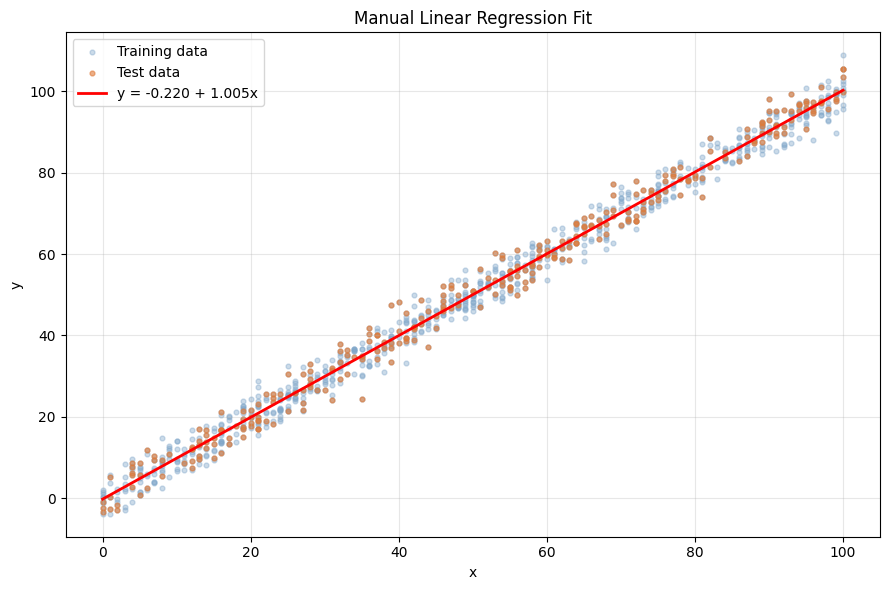

Final Model: y = -0.219537 + 1.004837 * x
Mean Squared Error on test set: 4.647847


In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))
plt.scatter(x_train, y_train, s=12, alpha=0.4, color='#7fa6c9', label='Training data')
plt.scatter(x_test, y_test, s=12, alpha=0.6, color='#e07b39', label='Test data')

line_x = [min(x_train + x_test), max(x_train + x_test)]
line_y = [predict(px, beta_0, beta_1) for px in line_x]
plt.plot(line_x, line_y, color='red', linewidth=2, label=f'y = {beta_0:.3f} + {beta_1:.3f}x')

plt.title('Manual Linear Regression Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final Model: y = {beta_0:.6f} + {beta_1:.6f} * x")
print(f"Mean Squared Error on test set: {mse:.6f}")

## 6. Conclusion

- $\beta_1$ and $\beta_0$ were computed from the training data using the $SS_{xy}/SS_{xx}$ formulas, implemented entirely with **plain Python loops** — no `numpy`, `pandas`, or `sklearn.linear_model`.
- Predictions were generated for every row of the test set, and the error $\varepsilon_i$ = predicted − actual was computed manually for each.
- The **Mean Squared Error** was computed with the given formula $\frac{1}{2n}\sum \varepsilon_i^2$, using pure Python.
- `matplotlib` was used only at the end to visualize the fitted line — it played no role in the regression math.
